# ML Model Comparison — XGBoost, LightGBM, CatBoost

**Tree-based gradient boosting models for Probability of Default (PD) estimation on Lending Club 2007–2014, compared against the WoE + LASSO baseline.**

📄 [Read the full paper](../Uzun_B_2022_PD_Model_Comparison.pdf)

| Model | AUC | KS | Brier Score | Accuracy |
|-------|-----|----|-------------|----------|
| **XGBoost** | **0.702** | **0.298** | **0.068** | 89.6% |
| CatBoost | 0.696 | 0.288 | 0.065 | 90.4% |
| LightGBM | 0.621 | 0.130 | 0.082 | 84.4% |
| LASSO (WoE baseline) | 0.689 | 0.276 | 0.072 | 74.5% |

**Key finding:** XGBoost achieves the highest AUC (70.2%) and KS (29.8%), outperforming the traditional WoE+LASSO approach in discriminatory power — without requiring manual WoE binning.

> **Note:** Training feature matrix (`X_train`) not included due to file size (~300MB). Test features available at `data/ml/X_test.csv`. Raw data: [Lending Club on Kaggle](https://www.kaggle.com/datasets/wordsforthewise/lending-club).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, plot_roc_curve, roc_curve, brier_score_loss
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV, cross_val_score
import xgboost as xgb
import lightgbm as lgbm
import catboost as cat
import warnings
from sklearn import ensemble
import seaborn as sns
import sklearn.linear_model as linear_model
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn import model_selection
from sklearn.preprocessing import StandardScaler
import scipy.stats as stat
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import optuna
from optuna import Trial, visualization
from optuna.samplers import TPESampler
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [2]:
#Creating the Dataset Without WoE Groupings
X_train1 = pd.read_csv('mldata/X_trainnew.csv', index_col = 0)
X_test1 = pd.read_csv('mldata/X_testnew.csv', index_col=0)
y_train1 = pd.read_csv('mldata/y_trainnew.csv', index_col=0)
y_test1 = pd.read_csv('mldata/y_testnew.csv', index_col=0)
#X_train1 = X_train1.loc[:, ['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'home_ownership:ANY', 'home_ownership:MORTGAGE', 'home_ownership:NONE', 'home_ownership:OTHER', 'home_ownership:OWN', 'home_ownership:RENT', 'addr_state:AK', 'addr_state:AL', 'addr_state:AR','addr_state:AZ', 'addr_state:CA', 'addr_state:CO', 'addr_state:CT','addr_state:DC', 'addr_state:DE', 'addr_state:FL', 'addr_state:GA', 'addr_state:HI', 'addr_state:IA', 'addr_state:ID', 'addr_state:IL',
'addr_state:IN', 'addr_state:KS', 'addr_state:KY', 'addr_state:LA','addr_state:MA', 'addr_state:MD', 'addr_state:ME', 'addr_state:MI','addr_state:MN', 'addr_state:MO', 'addr_state:MS', 'addr_state:MT','addr_state:NC', 'addr_state:NE', 'addr_state:NH', 'addr_state:NJ','addr_state:NM', 'addr_state:NV', 'addr_state:NY', 'addr_state:OH',
'addr_state:OK', 'addr_state:OR', 'addr_state:PA', 'addr_state:RI','addr_state:SC', 'addr_state:SD', 'addr_state:TN', 'addr_state:TX','addr_state:UT', 'addr_state:VA', 'addr_state:VT', 'addr_state:WA','addr_state:WI', 'addr_state:WV', 'addr_state:WY', 'initial_list_status:f','initial_list_status:w', 'verification_status:Not Verified', 'verification_status:Source Verified', 'verification_status:Verified', 'purpose:house', 'purpose:major_purchase', 'purpose:medical', 'purpose:moving', 'purpose:other','purpose:renewable_energy','purpose:small_business', 'purpose:vacation','purpose:wedding', 'emp_length_int', 'term', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record', 'loan_amnt']]
#X_test1 = X_test1.loc[:, ['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'home_ownership:ANY', 'home_ownership:MORTGAGE', 'home_ownership:NONE', 'home_ownership:OTHER', 'home_ownership:OWN', 'home_ownership:RENT', 'addr_state:AK', 'addr_state:AL', 'addr_state:AR','addr_state:AZ', 'addr_state:CA', 'addr_state:CO', 'addr_state:CT','addr_state:DC', 'addr_state:DE', 'addr_state:FL', 'addr_state:GA', 'addr_state:HI', 'addr_state:IA', 'addr_state:ID', 'addr_state:IL',
'addr_state:IN', 'addr_state:KS', 'addr_state:KY', 'addr_state:LA','addr_state:MA', 'addr_state:MD', 'addr_state:ME', 'addr_state:MI','addr_state:MN', 'addr_state:MO', 'addr_state:MS', 'addr_state:MT','addr_state:NC', 'addr_state:NE', 'addr_state:NH', 'addr_state:NJ','addr_state:NM', 'addr_state:NV', 'addr_state:NY', 'addr_state:OH',
'addr_state:OK', 'addr_state:OR', 'addr_state:PA', 'addr_state:RI','addr_state:SC', 'addr_state:SD', 'addr_state:TN', 'addr_state:TX','addr_state:UT', 'addr_state:VA', 'addr_state:VT', 'addr_state:WA','addr_state:WI', 'addr_state:WV', 'addr_state:WY', 'initial_list_status:f','initial_list_status:w', 'verification_status:Not Verified', 'verification_status:Source Verified', 'verification_status:Verified', 'purpose:house', 'purpose:major_purchase', 'purpose:medical', 'purpose:moving', 'purpose:other','purpose:renewable_energy','purpose:small_business', 'purpose:vacation','purpose:wedding', 'emp_length_int', 'term', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record', 'loan_amnt']]
print(X_train1.shape, X_test1.shape, y_train1.shape, y_test1.shape)
X_train1.head()

(326399, 93) (139886, 93) (326399, 1) (139886, 1)


,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,...,open_acc,pub_rec,total_acc,acc_now_delinq,total_rev_hi_lim,annual_inc,dti,mths_since_last_delinq,mths_since_last_record,loan_amnt
42516,0,0,1,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1400.0,40000.0,8.61,NaN,NaN,1400
42526,0,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,3000.0,35000.0,10.00,NaN,NaN,3000
42527,0,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,3000.0,20000.0,10.00,NaN,NaN,3000
42528,0,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,2000.0,6000.0,10.00,NaN,NaN,2000
42529,0,1,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,6500.0,20000.0,10.00,NaN,NaN,6500


## 2. Feature Engineering

93 features: one-hot encoded categorical variables (grade, state, purpose, home ownership) + continuous variables (int_rate, dti, annual_inc, etc.) + WoE-grouped bins for employment length and delinquency history. No manual WoE transformation of the main variables — tree models handle splits automatically.

In [3]:
#One Hot Encoding
#def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    #dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    #return dataframe
#ohe_cols = ['term']
#X_train1 = one_hot_encoder(X_train1, ohe_cols,drop_first=True)
#X_test1 = one_hot_encoder(X_test1, ohe_cols,drop_first=True)


In [5]:
X_train1.columns.values

array(['grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G'],
      dtype=object)

In [8]:
print(X_train1.columns.values)


['mths_since_issue_d' 'int_rate' 'mths_since_earliest_cr_line'
 'delinq_2yrs' 'inq_last_6mths' 'open_acc' 'pub_rec' 'total_acc'
 'acc_now_delinq' 'total_rev_hi_lim' 'annual_inc' 'dti' 'loan_amnt'
 'grade_B' 'grade_C' 'grade_D' 'grade_E' 'grade_F' 'grade_G'
 'home_ownership_NONE' 'home_ownership_OTHER' 'home_ownership_OWN'
 'home_ownership_RENT' 'addr_state_AL' 'addr_state_AR' 'addr_state_AZ'
 'addr_state_CA' 'addr_state_CO' 'addr_state_CT' 'addr_state_DC'
 'addr_state_DE' 'addr_state_FL' 'addr_state_GA' 'addr_state_HI'
 'addr_state_IA' 'addr_state_ID' 'addr_state_IL' 'addr_state_IN'
 'addr_state_KS' 'addr_state_KY' 'addr_state_LA' 'addr_state_MA'
 'addr_state_MD' 'addr_state_ME' 'addr_state_MI' 'addr_state_MN'
 'addr_state_MO' 'addr_state_MS' 'addr_state_MT' 'addr_state_NC'
 'addr_state_NE' 'addr_state_NH' 'addr_state_NJ' 'addr_state_NM'
 'addr_state_NV' 'addr_state_NY' 'addr_state_OH' 'addr_state_OK'
 'addr_state_OR' 'addr_state_PA' 'addr_state_RI' 'addr_state_SC'
 'addr_state_SD' 'ad

In [8]:
#s = ['emp_length_int', 'mths_since_last_record', 'mths_since_last_delinq', 'emp_length:0']
#X_train1.drop(s, axis=1, inplace=True)
#X_test1.drop(s, axis=1, inplace=True)
#X_train1.isnull().sum()
#X_train1.to_csv('mldata/X_trainnew.csv')
#X_test1.to_csv('mldata/X_testnew.csv')

In [ ]:
#Objection Function & Model Tuning with Optuna

#Objective function
def objective(trial):
    X_train1 = pd.read_csv('mldata/X_trainnew.csv', index_col = 0)
    X_test1 = pd.read_csv('mldata/X_testnew.csv', index_col=0)
    y_train1 = pd.read_csv('mldata/y_train.csv', index_col=0)
    y_test1 = pd.read_csv('mldata/y_test.csv', index_col=0)

 #X_train ve X_test düzenlenecek.

    #X_train1 = X_train1.loc[:, ['grade', 'home_ownership', 'addr_state', 'verification_status', 'purpose', 'emp_length_int', 'initial_list_status', 'term', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record']]
    #X_test1 = X_test1.loc[:, ['grade', 'home_ownership', 'addr_state', 'verification_status', 'purpose', 'emp_length_int', 'initial_list_status', 'term', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record']]


    params = {

        'objective': 'binary:logistic',

        'max_depth': trial.suggest_int('max_depth', 1, 9),

        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),

        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-8, 1.0)

    }



    clf_gbt = xgb.XGBClassifier(**params, use_label_encoder=False)

    clf_gbt.fit(X_train1, np.ravel(y_train1), eval_metric = 'error')



    gbt_preds = clf_gbt.predict(X_test1)



    accuracy = accuracy_score(y_test1, gbt_preds)

    return (1-accuracy)



if __name__ == '__main__':



    study = optuna.create_study()

    study.optimize(objective, n_trials=75)



    print(study.best_params)

## 3. Model 1: XGBoost — Hyperparameter Tuning (Optuna)

Bayesian optimization via Optuna (75 trials, TPE sampler). Search space: `max_depth` ∈ [1,9], `n_estimators` ∈ [10,1000], `learning_rate` ∈ [1e-8, 1.0].

**Best parameters:** `max_depth=5`, `n_estimators=348`, `learning_rate=0.00701`

In [ ]:
#best params = {'max_depth': 5, 'n_estimators': 348, 'learning_rate': 0.007011120300802943}

In [7]:
#Training the model
clf_gbt = xgb.XGBClassifier(max_depth = 5, n_estimators = 348, learning_rate = 0.007011120300802943).fit(X_train1, np.ravel(y_train1), eval_metric = "error")

In [11]:
y_probs_xg = clf_gbt.predict_proba(X_test1)
y_probs_xg

array([[0.13052285, 0.86947715],
       [0.09989071, 0.9001093 ],
       [0.09733981, 0.9026602 ],
       ...,
       [0.10462838, 0.8953716 ],
       [0.17816943, 0.8218306 ],
       [0.10227406, 0.89772594]], dtype=float32)

In [12]:
y_probs_xg = y_probs_xg[: ][:, 1]
y_probs_xg

array([0.86947715, 0.9001093 , 0.9026602 , ..., 0.8953716 , 0.8218306 ,
       0.89772594], dtype=float32)

In [ ]:
xg_actual_predicted_probs.columns = ['y_test', 'y_hat_probs']
xg_actual_predicted_probs.index = y_test1.index
# Align index to match test set
xg_actual_predicted_probs['y_hat_test'] = np.where(xg_actual_predicted_probs['y_hat_probs'] > 0.80, 1, 0)
xg_actual_predicted_probs.head()

In [14]:
xg_actual_predicted_probs.columns = ['y_test', 'y_hat_probs']
xg_actual_predicted_probs.index = y_test1.index
# Datasetlerin indexleri eşitlendi.
xg_actual_predicted_probs['y_hat_test'] = np.where(xg_actual_predicted_probs['y_hat_probs'] > 0.80, 1, 0)
xg_actual_predicted_probs.head()

,y_test,y_hat_probs,y_hat_test
0,1,0.869477,1
1,1,0.900109,1
2,1,0.902660,1
3,1,0.874449,1
4,1,0.857890,1


In [15]:
#Accuracy
(pd.crosstab(xg_actual_predicted_probs['y_test'], xg_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / xg_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(xg_actual_predicted_probs['y_test'], xg_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / xg_actual_predicted_probs.shape[0]).iloc[1, 1]

0.8604077606050641

In [16]:
area_under_curve = roc_auc_score(xg_actual_predicted_probs['y_test'], xg_actual_predicted_probs['y_hat_probs'])

area_under_curve

0.6969478198618253

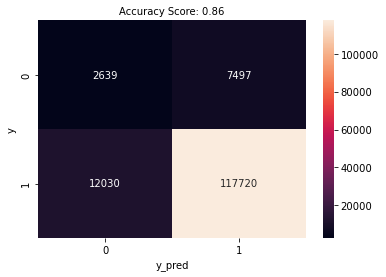

In [17]:
def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt=".0f")
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score: {0}'.format(acc), size=10)
    plt.show()

plot_confusion_matrix(y_test1, xg_actual_predicted_probs['y_hat_test'])

In [18]:
xg_preds = clf_gbt.predict(X_test1)
target_names = ['Default', 'Non-Default']
print(classification_report(np.ravel(y_test1), xg_actual_predicted_probs['y_hat_test'], target_names = target_names))

              precision    recall  f1-score   support

     Default       0.18      0.26      0.21     10136
 Non-Default       0.94      0.91      0.92    129750

    accuracy                           0.86    139886
   macro avg       0.56      0.58      0.57    139886
weighted avg       0.89      0.86      0.87    139886



In [19]:
#Brier Score
print('Brier Score of the XGboost Model:', brier_score_loss(y_test1, y_probs_xg))

Brier Score of the XGboost Model: 0.06833336633546815


In [ ]:
false_positive, true_positive, thresholds = roc_curve(xg_actual_predicted_probs['y_test'],
                                                      xg_actual_predicted_probs['y_hat_probs'])

## 4. XGBoost — Discriminatory Power (GINI & KS)

# Calculation Of GINI and Kolmogorov-Smirnov

In [ ]:
#Evaluation of The XGB Model Performance Gini and Kolmogorov-Smirnov
#First dataframe should sort by the probability values.
xg_actual_predicted_probs = xg_actual_predicted_probs.sort_values('y_hat_probs')
#Index Reset
xg_actual_predicted_probs = xg_actual_predicted_probs.reset_index()
xg_actual_predicted_probs.head()

In [ ]:
#Cumulative Observation Population
#"+1" is required because Python indexing starts at 0.
xg_actual_predicted_probs['Cumulative N Population'] = xg_actual_predicted_probs.index + 1
#Cumulative Number of Good Observations
xg_actual_predicted_probs['Cumulative N Good'] = xg_actual_predicted_probs['y_test'].cumsum()
#Cumulative Number of Bad Observations
xg_actual_predicted_probs['Cumulative N Bad'] = xg_actual_predicted_probs['Cumulative N Population'] - xg_actual_predicted_probs['y_test'].cumsum()

xg_actual_predicted_probs.head()

In [ ]:
#Percentage Values of The Cumulative Amounts
#Cumulative Percentage of all observations
xg_actual_predicted_probs['Cumulative Perc Population'] = xg_actual_predicted_probs['Cumulative N Population'] / (xg_actual_predicted_probs.shape[0])
#Cumulative Percentage of Good Obs
xg_actual_predicted_probs['Cumulative Perc Good'] = xg_actual_predicted_probs['Cumulative N Good'] / xg_actual_predicted_probs['y_test'].sum()
#Cumulative Percantage of Bad Obs
xg_actual_predicted_probs['Cumulative Perc Bad'] = xg_actual_predicted_probs['Cumulative N Bad'] / (xg_actual_predicted_probs.shape[0] - xg_actual_predicted_probs['y_test'].sum())

xg_actual_predicted_probs.head()

In [ ]:
# Plot Gini
plt.plot(xg_actual_predicted_probs['Cumulative Perc Population'], xg_actual_predicted_probs['Cumulative Perc Bad'])
plt.plot(xg_actual_predicted_probs['Cumulative Perc Population'], xg_actual_predicted_probs['Cumulative Perc Population'], linestyle = '--', color = 'k')
plt.xlabel('Cumulative % Population')
plt.ylabel('Cumulative % Bad')
plt.title('Gini')


In [ ]:
#Calculation of GINI with AUC.
GINI = (area_under_curve * 2) - 1
GINI

In [ ]:
#Kolmogorov-Smirnov
# Plot KS
plt.plot(xg_actual_predicted_probs['y_hat_probs'], xg_actual_predicted_probs['Cumulative Perc Bad'], color='red')

plt.plot(xg_actual_predicted_probs['y_hat_probs'], xg_actual_predicted_probs['Cumulative Perc Good'], color='blue')

plt.xlabel('Estimated Probability for being Good')
#"Estimated Probability for being Good".
plt.ylabel('Cumulative %')
#Cumulative
plt.title('Kolmogorov-Smirnov')
#KS


## 5. XGBoost — Feature Importance

Top predictors: `int_rate` (21.5%), `grade:C` (9.7%), `grade:B` (6.2%), `mths_since_issue_d` (5.6%). Interest rate dominates — consistent with economic intuition that higher-risk borrowers are charged higher rates.

# Feature Importance

In [9]:
feature_imp = pd.Series(clf_gbt.feature_importances_,index=X_train1.columns).sort_values(ascending=False)
feature_imp


int_rate                  0.215071
grade:C                   0.096879
grade:B                   0.062107
mths_since_issue_d        0.056056
grade:D                   0.055558
                            ...   
addr_state:MA             0.000000
purpose:house             0.000000
purpose:major_purchase    0.000000
purpose:medical           0.000000
addr_state:TN             0.000000
Length: 107, dtype: float32

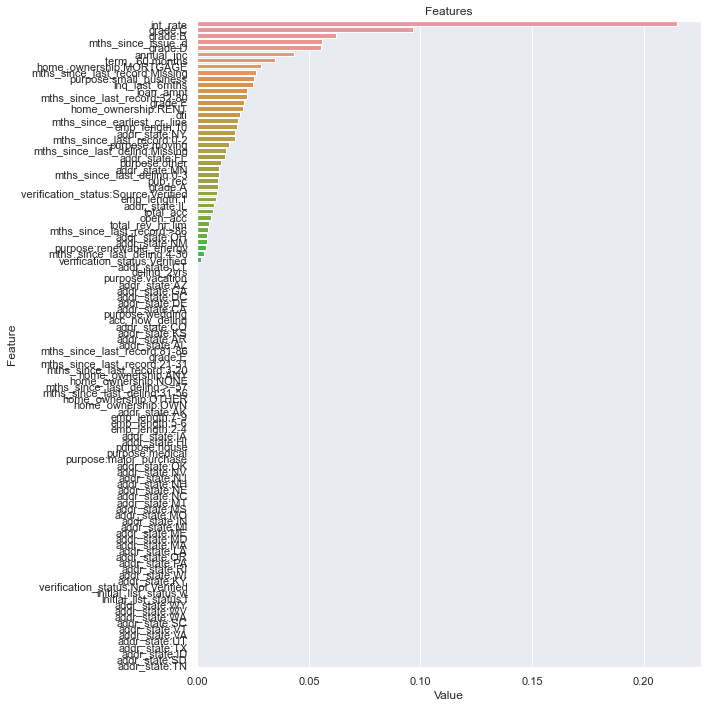

In [20]:
def plot_importance(model, features, num=len(X_train1), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')


plot_importance(clf_gbt, X_train1)

## 6. Model 2: LightGBM — Hyperparameter Tuning (Optuna)

**Best parameters:** `max_depth=6`, `n_estimators=565`, `learning_rate=1.0e-8`  
LightGBM uses leaf-wise (vertical) tree growth vs. XGBoost's level-wise approach — faster training but more prone to overfitting on smaller datasets.

# Light GBM

In [ ]:
def objective(trial):
    X_train1 = pd.read_csv('mldata/finalX_train1.csv', index_col = 0)
    X_test1 = pd.read_csv('mldata/finalX_test1.csv', index_col=0)
    y_train1 = pd.read_csv('mldata/y_train.csv', index_col=0)
    y_test1 = pd.read_csv('mldata/y_test.csv', index_col=0)

    #X_train ve X_test düzenlenecek.

    #X_train1 = X_train1.loc[:, ['grade', 'home_ownership', 'addr_state', 'verification_status', 'purpose', 'emp_length_int', 'initial_list_status', 'term', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record']]
    #X_test1 = X_test1.loc[:, ['grade', 'home_ownership', 'addr_state', 'verification_status', 'purpose', 'emp_length_int', 'initial_list_status', 'term', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record']]


    params = {

        'objective': 'binary',

        'max_depth': trial.suggest_int('max_depth', 1, 9),

        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),

        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-8, 1.0)

    }



    light_gbt = lgbm.LGBMClassifier(**params)

    light_gbt.fit(X_train1, np.ravel(y_train1), eval_metric = 'error')



    lgbm_preds = light_gbt.predict(X_test1)



    accuracy = accuracy_score(y_test1, lgbm_preds)

    return (1-accuracy)



if __name__ == '__main__':



    study = optuna.create_study()

    study.optimize(objective, n_trials=75)



    print(study.best_params)

## 7. Model 3: CatBoost — Hyperparameter Tuning (Optuna)

**Best parameters:** `max_depth=2`, `n_estimators=589`, `learning_rate=0.0189`  
CatBoost (Yandex, 2018) provides native handling of categorical features via ordered target statistics — well-suited to this dataset's many categorical variables (grade, state, purpose).

In [ ]:
def plot_importance(model, features, num=len(X_train1), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')

light_gbm = lgbm.LGBMClassifier(max_depth = 6, n_estimators = 565, learning_rate = 1.0017229232072383e-08).fit(X_train1, np.ravel(y_train1))

plot_importance(light_gbm, X_train1)



In [ ]:
def objective(trial):
    X_train1 = pd.read_csv('mldata/finalX_train1.csv', index_col = 0)
    X_test1 = pd.read_csv('mldata/finalX_test1.csv', index_col=0)
    y_train1 = pd.read_csv('mldata/y_train.csv', index_col=0)
    y_test1 = pd.read_csv('mldata/y_test.csv', index_col=0)

    #X_train ve X_test düzenlenecek.

    #X_train1 = X_train1.loc[:, ['grade', 'home_ownership', 'addr_state', 'verification_status', 'purpose', 'emp_length_int', 'initial_list_status', 'term', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record']]
    #X_test1 = X_test1.loc[:, ['grade', 'home_ownership', 'addr_state', 'verification_status', 'purpose', 'emp_length_int', 'initial_list_status', 'term', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record']]


    params = {


        'max_depth': trial.suggest_int('max_depth', 1, 9),

        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),

        'learning_rate': trial.suggest_loguniform('learning_rate', 0.00001, 1.0)

    }



    catb = cat.CatBoostClassifier(**params, verbose = False)

    catb.fit(X_train1, np.ravel(y_train1))



    cat_preds = catb.predict(X_test1)



    accuracy = accuracy_score(y_test1, cat_preds)

    return (1-accuracy)



if __name__ == '__main__':



    study = optuna.create_study()

    study.optimize(objective, n_trials=75)



    print(study.best_params)

## 8. Results Summary

| Model | AUC | KS | Brier Score | Accuracy | # True Defaults Caught |
|-------|-----|----|-------------|----------|----------------------|
| **XGBoost** | **0.702** | **0.298** | **0.068** | 89.6% | 1,483 |
| CatBoost | 0.696 | 0.288 | 0.065 | 90.4% | 1,147 |
| Random Forest | 0.673 | 0.254 | 0.068 | 83.6% | 2,873 |
| LightGBM | 0.621 | 0.130 | 0.082 | 84.4% | 1,792 |
| Decision Tree | 0.582 | 0.120 | 0.070 | 90.1% | 647 |
| **LASSO (WoE)** | 0.689 | 0.276 | 0.072 | 74.5% | **4,811** |
| Logistic Reg (WoE) | 0.691 | 0.278 | 0.071 | 75.8% | 4,648 |
| XGBoost (WoE) | 0.687 | 0.272 | 0.074 | 70.9% | 5,347 |

**Conclusion:** XGBoost leads on AUC and KS (best discriminatory power). However, WoE-based models catch far more actual defaults in absolute numbers — because WoE grouping specifically penalizes bad borrowers. XGBoost(WoE) catches the most defaults (5,347) while maintaining competitive AUC. Under Basel III regulatory constraints, WoE models remain the industry standard for interpretability; XGBoost represents the frontier once explainability requirements are met.

In [ ]:
X_train1.tail()